In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Cấu hình hiển thị
pd.set_option('display.max_colwidth', 150)
sns.set_theme(style="whitegrid")

# --- PHẦN CẤU HÌNH ĐƯỜNG DẪN (Bạn thay path thật vào đây) ---
path_triet_hoc = './result/MC_triet_hoc_result.csv'
path_tu_tuong_hcm = './result/MC_tu_tuong_hcm_result.csv'
path_ls_dang = './result/MC_lich_su_dang_result.csv'

# Danh sách các Model cần đánh giá (Tên cột trong CSV)
models = ['EduRAG', 'ChatGPT', 'QWEN', 'DeepSeek', 'Claude']
ground_truth_col = 'Câu trả lời'

# Hàm đọc và gán nhãn môn học
def load_and_label(path, subject_name):
    try:
        # Đọc file, giả sử encoding utf-8 (nếu lỗi font thử 'utf-16' hoặc 'latin1')
        df = pd.read_csv(path) 
        df['Mon_hoc'] = subject_name
        return df
    except Exception as e:
        print(f"Lỗi không đọc được file {subject_name}: {e}")
        return pd.DataFrame()

# 1. Load dữ liệu
df_triet = load_and_label(path_triet_hoc, 'Triết học')
df_hcm = load_and_label(path_tu_tuong_hcm, 'Tư tưởng HCM')
df_su = load_and_label(path_ls_dang, 'Lịch sử Đảng')

# 2. Gộp thành 1 DataFrame tổng
df_all = pd.concat([df_triet, df_hcm, df_su], ignore_index=True)

print(f"Tổng số câu hỏi: {len(df_all)}")
print(f"Số lượng câu theo môn:\n{df_all['Mon_hoc'].value_counts()}")

# 3. Tiền xử lý (Chuẩn hóa text về chữ in hoa, xóa khoảng trắng thừa)
cols_to_clean = models + [ground_truth_col]
for col in cols_to_clean:
    # Chuyển về string, strip và upper để so sánh 'A' == 'a '
    df_all[col] = df_all[col].astype(str).str.strip().str.upper()

display(df_all.head())

Tổng số câu hỏi: 200
Số lượng câu theo môn:
Mon_hoc
Tư tưởng HCM    80
Triết học       60
Lịch sử Đảng    60
Name: count, dtype: int64


,STT,Câu hỏi,Câu trả lời,EduRAG,ChatGPT,QWEN,DeepSeek,Claude,Mon_hoc
0,1,"Triết học ra đời ở cả phương Đông và phương Tây gần như cùng một thời gian, khoảng thế kỷ nào? A. X đến VIII trước Công nguyên. B. VIII đến VI trư...",B,B,B,B,B,B,Triết học
1,2,"Ở Trung Quốc, thuật ngữ triết học có gốc ngôn ngữ là chữ gì? A. Đạo B. Lý C. Triết D. Tuệ",C,C,C,C,C,C,Triết học
2,3,"Theo C. Mác, vào cuối thế kỷ XVIII ở Pháp, triết học duy nhất triệt để, trung thành với tất cả mọi học thuyết của khoa học tự nhiên, thù địch với ...",B,B,C,B,B,C,Triết học
3,4,Vấn đề cơ bản lớn nhất của triết học là mối quan hệ giữa đối tượng nào? A. Mối quan hệ giữa vật chất và không gian. B. Mối quan hệ giữa ý thức và ...,C,C,C,C,C,C,Triết học
4,5,Việc giải quyết mặt thứ nhất vấn đề cơ bản của triết học đã chia các nhà triết học thành hai trường phái lớn nào? A. Biện chứng và Siêu hình. B. D...,C,C,C,C,C,C,Triết học


C:\Users\dhdnc\AppData\Local\Temp\ipykernel_13244\637749072.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[0], x='Model', y='Accuracy', data=overall_df, palette='viridis')


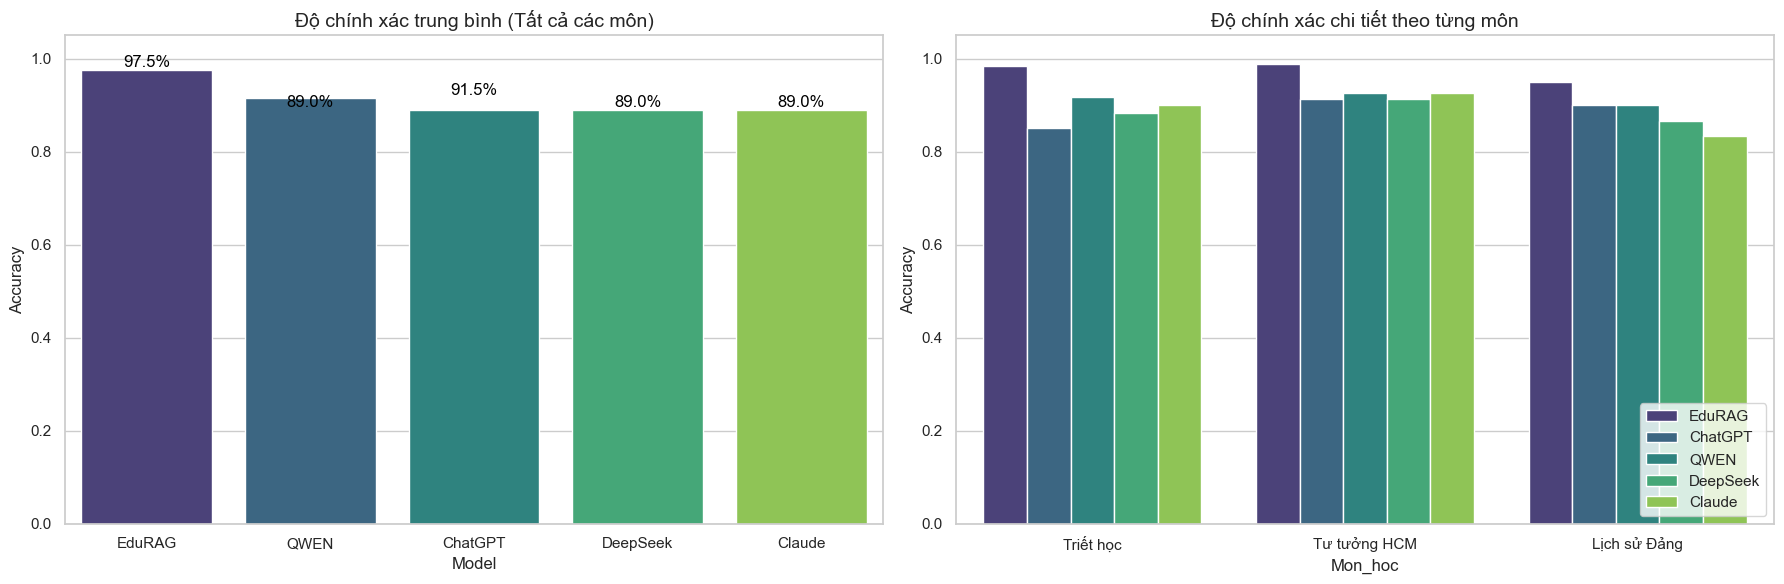

Bảng chi tiết độ chính xác theo môn:


,EduRAG_correct,ChatGPT_correct,QWEN_correct,DeepSeek_correct,Claude_correct
Mon_hoc,,,,,
Lịch sử Đảng,0.950000,0.9000,0.900000,0.866667,0.833333
Triết học,0.983333,0.8500,0.916667,0.883333,0.900000
Tư tưởng HCM,0.987500,0.9125,0.925000,0.912500,0.925000


In [8]:
# Tạo DataFrame lưu kết quả đúng sai (True/False)
eval_df = df_all.copy()
for model in models:
    eval_df[f'{model}_correct'] = df_all[model] == df_all[ground_truth_col]

# --- 1. TÍNH ACCURACY TỔNG THỂ (Overall) ---
overall_acc = eval_df[[f'{m}_correct' for m in models]].mean()
overall_df = overall_acc.reset_index()
overall_df.columns = ['Model_Col', 'Accuracy']
overall_df['Model'] = overall_df['Model_Col'].str.replace('_correct', '')
overall_df = overall_df.sort_values(by='Accuracy', ascending=False)

# --- 2. TÍNH ACCURACY THEO TỪNG MÔN (Per Subject) ---
# Group by Môn học và tính mean cho các cột correct
subject_acc = eval_df.groupby('Mon_hoc')[[f'{m}_correct' for m in models]].mean()
# Transpose để dễ vẽ (Dòng là Model, Cột là Môn)
subject_acc_plot = subject_acc.T.reset_index()
subject_acc_plot['Model'] = subject_acc_plot['index'].str.replace('_correct', '')
# Melt data để vẽ biểu đồ cột ghép (Grouped Bar Chart)
subject_acc_melted = subject_acc_plot.melt(id_vars='Model', value_vars=['Triết học', 'Tư tưởng HCM', 'Lịch sử Đảng'], 
                                           var_name='Mon_hoc', value_name='Accuracy')

# --- VẼ BIỂU ĐỒ ---
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Biểu đồ 1: Tổng thể
sns.barplot(ax=axes[0], x='Model', y='Accuracy', data=overall_df, palette='viridis')
axes[0].set_title('Độ chính xác trung bình (Tất cả các môn)', fontsize=14)
axes[0].set_ylim(0, 1.05)
for index, row in overall_df.iterrows():
    axes[0].text(index, row.Accuracy, f'{row.Accuracy*100:.1f}%', color='black', ha="center", va="bottom")

# Biểu đồ 2: Chi tiết theo môn
sns.barplot(ax=axes[1], x='Mon_hoc', y='Accuracy', hue='Model', data=subject_acc_melted, palette='viridis')
axes[1].set_title('Độ chính xác chi tiết theo từng môn', fontsize=14)
axes[1].set_ylim(0, 1.05)
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.show()

print("Bảng chi tiết độ chính xác theo môn:")
display(subject_acc)

In [9]:
# Lọc ra các câu hỏi: EduRAG ĐÚNG và (Tất cả hoặc Đa số model khác SAI)
other_models = [m for m in models if m != 'EduRAG']

# Điều kiện 1: EduRAG đúng
cond_edurag = eval_df['EduRAG_correct'] == True

# Điều kiện 2: Tất cả model khác đều sai
cond_others_fail = (~eval_df[[f'{m}_correct' for m in other_models]]).all(axis=1)

hard_wins = df_all[cond_edurag & cond_others_fail]

print(f"Tổng số câu hỏi 'Hard Win' (EduRAG đúng, tất cả đối thủ sai): {len(hard_wins)}")

if len(hard_wins) > 0:
    print("Top 5 ví dụ điển hình:")
    # Hiển thị cột Môn học để biết câu khó nằm ở môn nào
    display(hard_wins[['Mon_hoc', 'Câu hỏi', 'Câu trả lời', 'EduRAG'] + other_models].head(5))
    
    # Thống kê xem môn nào EduRAG "gánh" nhiều nhất
    print("\nPhân bố các câu 'Hard Win' theo môn:")
    print(hard_wins['Mon_hoc'].value_counts())
else:
    print("Không có câu nào EduRAG thắng tuyệt đối. Hãy thử nới lỏng điều kiện (ví dụ: EduRAG đúng còn GPT sai).")

Tổng số câu hỏi 'Hard Win' (EduRAG đúng, tất cả đối thủ sai): 9
Top 5 ví dụ điển hình:


,Mon_hoc,Câu hỏi,Câu trả lời,EduRAG,ChatGPT,QWEN,DeepSeek,Claude
11,Triết học,Nội dung cơ bản đạo đức của Nho gia được tóm tắt trong hai phạm trù nào? A. Nhân - Nghĩa. B. Giới - Định - Tuệ. C. Luân - Thường. D. Trung - Hiếu.,C,C,A,A,A,A
53,Triết học,Phán đoán phổ biến là hình thức thể hiện nào của tư duy? A. Sự liên kết khái niệm. B. Sự bao quát rộng lớn nhất về đối tượng. C. Sự khẳng định hoặ...,B,B,A,C,A,C
60,Tư tưởng HCM,"Khái niệm ""Tư tưởng Hồ Chí Minh"" được Đảng Cộng sản Việt Nam nêu ra tại Đại hội nào? A. Đại hội IX (2001). B. Đại hội X (2006). C. Đại hội XI (201...",C,C,D,D,D,D
69,Tư tưởng HCM,Tư tưởng Hồ Chí Minh hình thành và phát triển qua mấy thời kỳ cơ bản? A. Hai. B. Ba. C. Bốn. D. Năm.,D,D,C,C,C,B
93,Tư tưởng HCM,"Theo Hồ Chí Minh, nguyên tắc nào là quan trọng bậc nhất trong xây dựng chủ nghĩa xã hội trong thời kỳ quá độ? A. Thống nhất giữa xây và chống. B. ...",B,B,A,C,A,A



Phân bố các câu 'Hard Win' theo môn:
Mon_hoc
Tư tưởng HCM    4
Lịch sử Đảng    3
Triết học       2
Name: count, dtype: int64
